# Task 3: Energy Consumption Time Series Forecasting

**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Forecast short-term household energy consumption using historical time-based patterns, comparing the performance of ARIMA, Prophet, and XGBoost models.

## Objective
- Parse and resample the Household Power Consumption time series
- Engineer time-based features (hour, weekday, etc.)
- Compare ARIMA, Prophet, and XGBoost forecasting models
- Evaluate with MAE and RMSE; plot actual vs. forecasted usage


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Core libraries loaded.")

# Prophet
try:
    from prophet import Prophet
    print("Prophet loaded.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'prophet', '-q'])
    from prophet import Prophet
    print("Prophet installed and loaded.")

# ARIMA
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    print("Statsmodels loaded.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    print("Statsmodels installed and loaded.")


Core libraries loaded.


Importing plotly failed. Interactive plots will not work.


Prophet installed and loaded.
Statsmodels installed and loaded.


## 2. Load & Parse Dataset

In [2]:
import urllib.request, io, gzip

url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "00235/household_power_consumption.zip")

print("Downloading Household Power Consumption dataset...")
import zipfile
response = urllib.request.urlopen(url)
zf = zipfile.ZipFile(io.BytesIO(response.read()))
with zf.open('household_power_consumption.txt') as f:
    df_raw = pd.read_csv(f, sep=';', low_memory=False,
                         na_values=['?'])

print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()


Loaded: 2,075,259 rows × 9 columns


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# Parse datetime and set index
df_raw['datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'],
                                     format='%d/%m/%Y %H:%M:%S')
df_raw = df_raw.set_index('datetime').drop(['Date','Time'], axis=1)
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

# Resample to hourly mean (reduces noise & size)
df_hourly = df_raw['Global_active_power'].resample('H').mean()
df_hourly = df_hourly.dropna()

print(f"Hourly series: {df_hourly.shape[0]:,} observations")
print(f"Date range: {df_hourly.index.min()} → {df_hourly.index.max()}")
df_hourly.head(10)


Hourly series: 34,168 observations
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
2006-12-16 22:00:00    2.200133
2006-12-16 23:00:00    2.061600
2006-12-17 00:00:00    1.882467
2006-12-17 01:00:00    3.349400
2006-12-17 02:00:00    1.587267
Name: Global_active_power, dtype: float64

## 3. Exploratory Data Analysis (EDA)

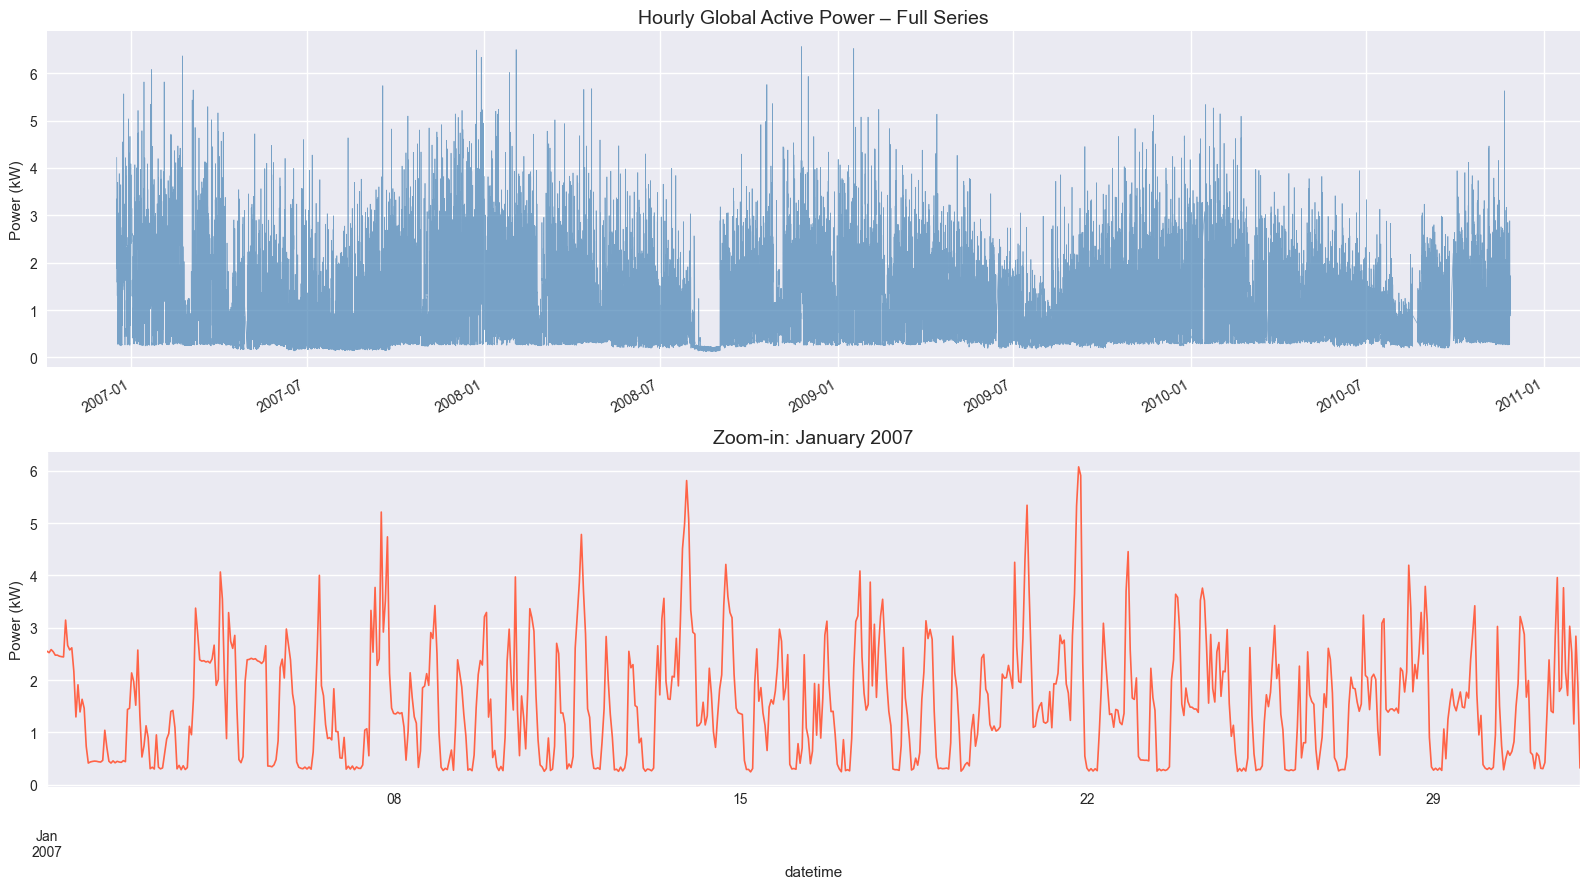

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Full series
df_hourly.plot(ax=axes[0], color='steelblue', alpha=0.7, linewidth=0.5)
axes[0].set_title('Hourly Global Active Power – Full Series', fontsize=14)
axes[0].set_ylabel('Power (kW)')
axes[0].set_xlabel('')

# One month zoom-in
sample = df_hourly['2007-01':'2007-01']
sample.plot(ax=axes[1], color='tomato', linewidth=1.2)
axes[1].set_title('Zoom-in: January 2007', fontsize=14)
axes[1].set_ylabel('Power (kW)')

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


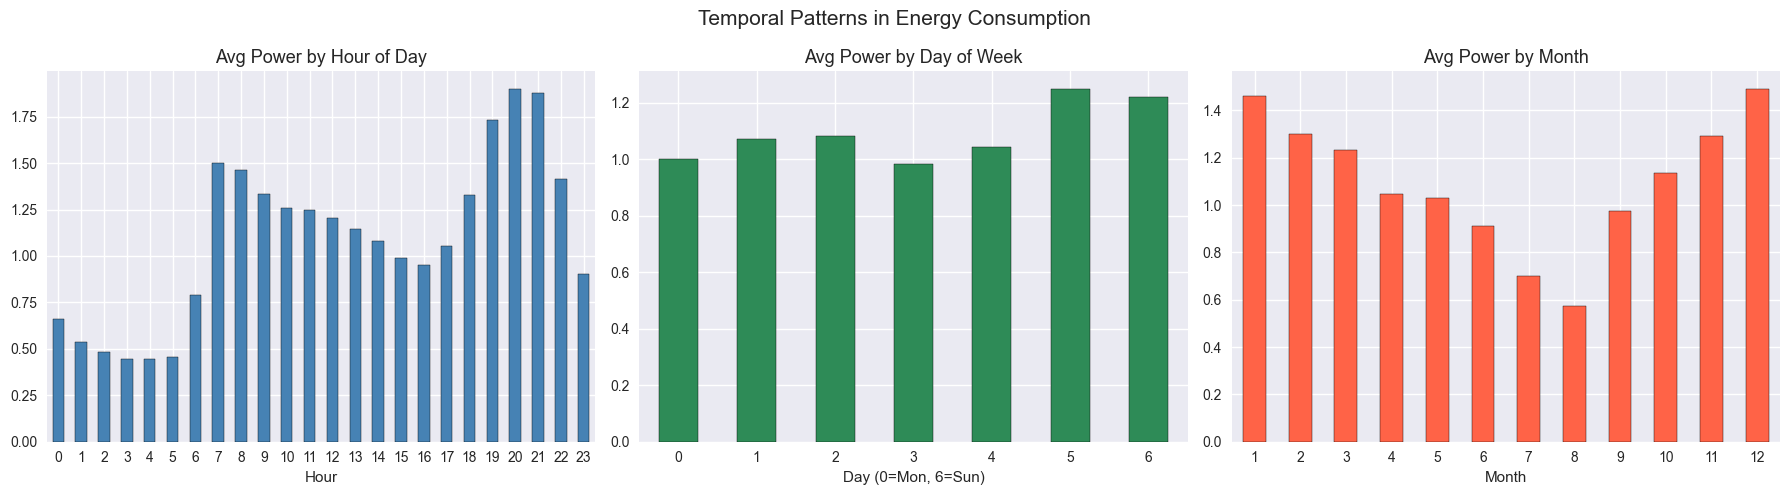

In [5]:
# Seasonal patterns
df_ts = df_hourly.to_frame(name='power')
df_ts['hour']    = df_ts.index.hour
df_ts['weekday'] = df_ts.index.dayofweek
df_ts['month']   = df_ts.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_ts.groupby('hour')['power'].mean().plot(kind='bar', ax=axes[0],
     color='steelblue', edgecolor='black')
axes[0].set_title('Avg Power by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour')
axes[0].tick_params(rotation=0)

df_ts.groupby('weekday')['power'].mean().plot(kind='bar', ax=axes[1],
     color='seagreen', edgecolor='black')
axes[1].set_title('Avg Power by Day of Week', fontsize=13)
axes[1].set_xlabel('Day (0=Mon, 6=Sun)')
axes[1].tick_params(rotation=0)

df_ts.groupby('month')['power'].mean().plot(kind='bar', ax=axes[2],
     color='tomato', edgecolor='black')
axes[2].set_title('Avg Power by Month', fontsize=13)
axes[2].set_xlabel('Month')
axes[2].tick_params(rotation=0)

plt.suptitle('Temporal Patterns in Energy Consumption', fontsize=15)
plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

In [6]:
# Work with last 6 months for faster model training
df_model = df_hourly['2010-06':].to_frame(name='power')

def engineer_features(df):
    d = df.copy()
    d['hour']         = d.index.hour
    d['dayofweek']    = d.index.dayofweek
    d['month']        = d.index.month
    d['dayofyear']    = d.index.dayofyear
    d['is_weekend']   = (d.index.dayofweek >= 5).astype(int)
    # Lag features
    for lag in [1, 2, 3, 24, 48, 168]:
        d[f'lag_{lag}h'] = d['power'].shift(lag)
    # Rolling features
    for win in [3, 6, 24]:
        d[f'roll_mean_{win}h'] = d['power'].rolling(win).mean()
        d[f'roll_std_{win}h']  = d['power'].rolling(win).std()
    return d

df_feat = engineer_features(df_model).dropna()
print(f"Feature-engineered dataset: {df_feat.shape}")
print("Features:", df_feat.columns.tolist())


Feature-engineered dataset: (3920, 18)
Features: ['power', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_24h', 'roll_std_24h']


## 5. Train / Test Split

In [7]:
# Use last 7 days as test set
split_date = df_feat.index[-24*7]
train = df_feat[df_feat.index < split_date]
test  = df_feat[df_feat.index >= split_date]

y_train = train['power']
y_test  = test['power']

feat_cols = [c for c in df_feat.columns if c != 'power']
X_train   = train[feat_cols]
X_test    = test[feat_cols]

print(f"Train: {train.shape[0]} rows ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {test.shape[0]} rows ({test.index.min().date()} → {test.index.max().date()})")


Train: 3752 rows (2010-06-08 → 2010-11-19)
Test : 168 rows (2010-11-19 → 2010-11-26)


## 6. Model 1: ARIMA

In [8]:
print("Fitting ARIMA(2,1,2)...")
# Use only the power column at daily frequency for ARIMA
arima_train = y_train.copy()
arima_test  = y_test.copy()

arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(steps=len(arima_test))
arima_pred.index = arima_test.index

arima_mae  = mean_absolute_error(arima_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(arima_test, arima_pred))
print(f"ARIMA MAE: {arima_mae:.4f} kW  |  RMSE: {arima_rmse:.4f} kW")


Fitting ARIMA(2,1,2)...


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecas

ARIMA MAE: 0.6926 kW  |  RMSE: 0.8535 kW


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 7. Model 2: Prophet

In [9]:
print("Fitting Prophet...")
# Prophet requires 'ds' and 'y' columns
prophet_train = y_train.reset_index().rename(columns={'datetime':'ds','power':'y'})
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True,
                         yearly_seasonality=False, changepoint_prior_scale=0.05)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(y_test), freq='H')
prophet_forecast = prophet_model.predict(future)

# Align predictions to test period
prophet_pred = prophet_forecast.set_index('ds')['yhat'].loc[y_test.index]
prophet_pred = prophet_pred.clip(lower=0)

prophet_mae  = mean_absolute_error(y_test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y_test, prophet_pred))
print(f"Prophet MAE: {prophet_mae:.4f} kW  |  RMSE: {prophet_rmse:.4f} kW")


Fitting Prophet...


19:08:03 - cmdstanpy - INFO - Chain [1] start processing
19:08:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.5634 kW  |  RMSE: 0.7325 kW


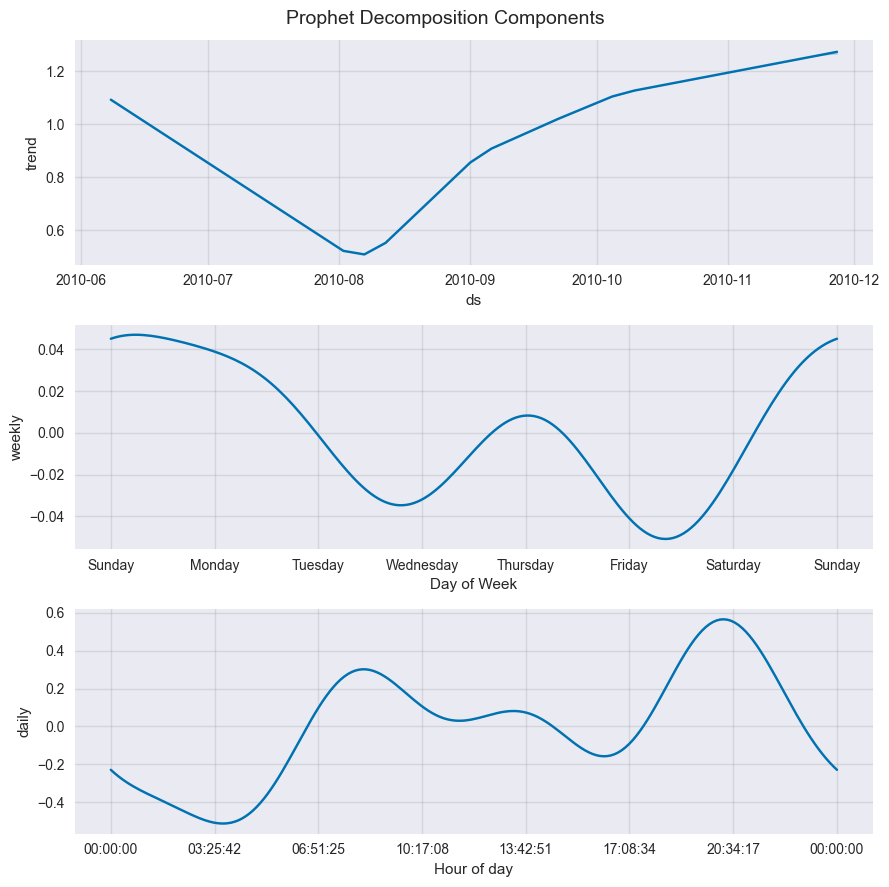

In [10]:
# Prophet components
fig = prophet_model.plot_components(prophet_forecast)
fig.suptitle('Prophet Decomposition Components', fontsize=14)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model 3: XGBoost

In [11]:
print("Fitting XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric='rmse', n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=100)

xgb_pred  = pd.Series(xgb_model.predict(X_test), index=y_test.index)
xgb_mae   = mean_absolute_error(y_test, xgb_pred)
xgb_rmse  = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost MAE: {xgb_mae:.4f} kW  |  RMSE: {xgb_rmse:.4f} kW")


Fitting XGBoost...
[0]	validation_0-rmse:0.84175
[100]	validation_0-rmse:0.21960
[200]	validation_0-rmse:0.20204
[300]	validation_0-rmse:0.19909
[400]	validation_0-rmse:0.19806
[499]	validation_0-rmse:0.19760
XGBoost MAE: 0.0854 kW  |  RMSE: 0.1976 kW


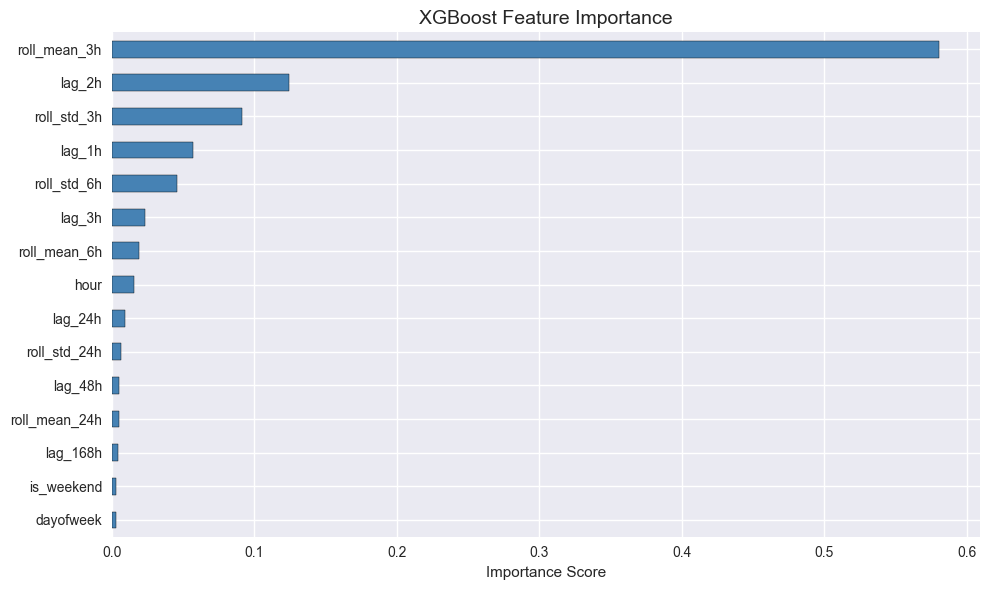

In [12]:
# XGBoost feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Model Comparison & Visualisation

In [13]:
# Performance comparison
results_df = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE':   [arima_mae,  prophet_mae,  xgb_mae],
    'RMSE':  [arima_rmse, prophet_rmse, xgb_rmse]
}).set_index('Model')
print("=== Model Performance Comparison ===")
print(results_df.round(4))
results_df


=== Model Performance Comparison ===
            MAE    RMSE
Model                  
ARIMA    0.6926  0.8535
Prophet  0.5634  0.7325
XGBoost  0.0854  0.1976


,MAE,RMSE
Model,,
ARIMA,0.692582,0.853472
Prophet,0.563371,0.732473
XGBoost,0.085380,0.197555


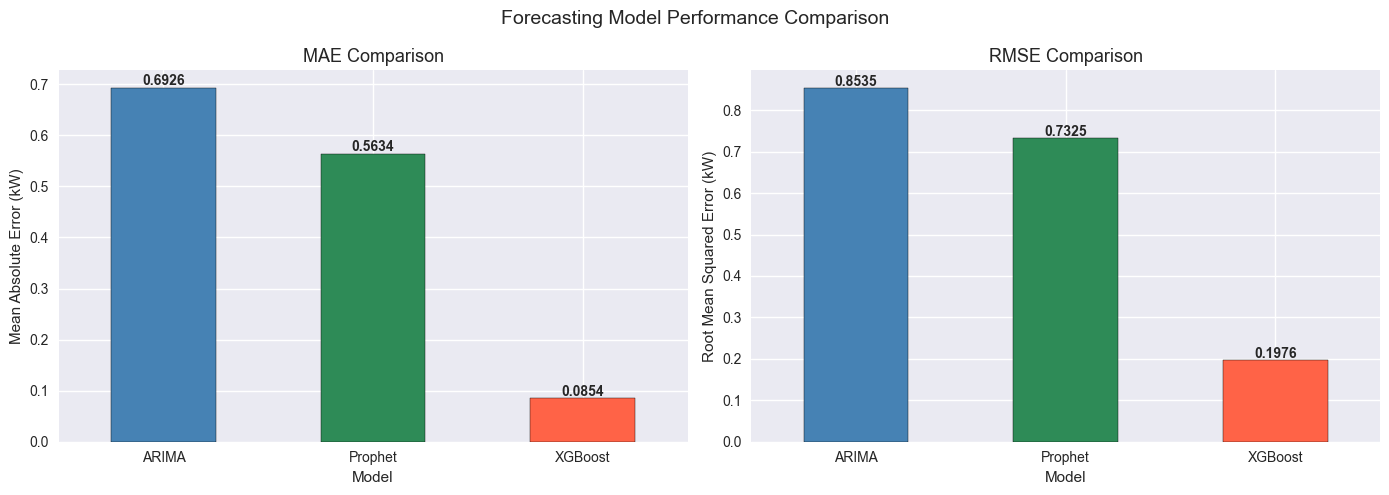

In [14]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'seagreen', 'tomato']

results_df['MAE'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('MAE Comparison', fontsize=13)
axes[0].set_ylabel('Mean Absolute Error (kW)')
axes[0].tick_params(rotation=0)
for i, v in enumerate(results_df['MAE']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

results_df['RMSE'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('RMSE Comparison', fontsize=13)
axes[1].set_ylabel('Root Mean Squared Error (kW)')
axes[1].tick_params(rotation=0)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Forecasting Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


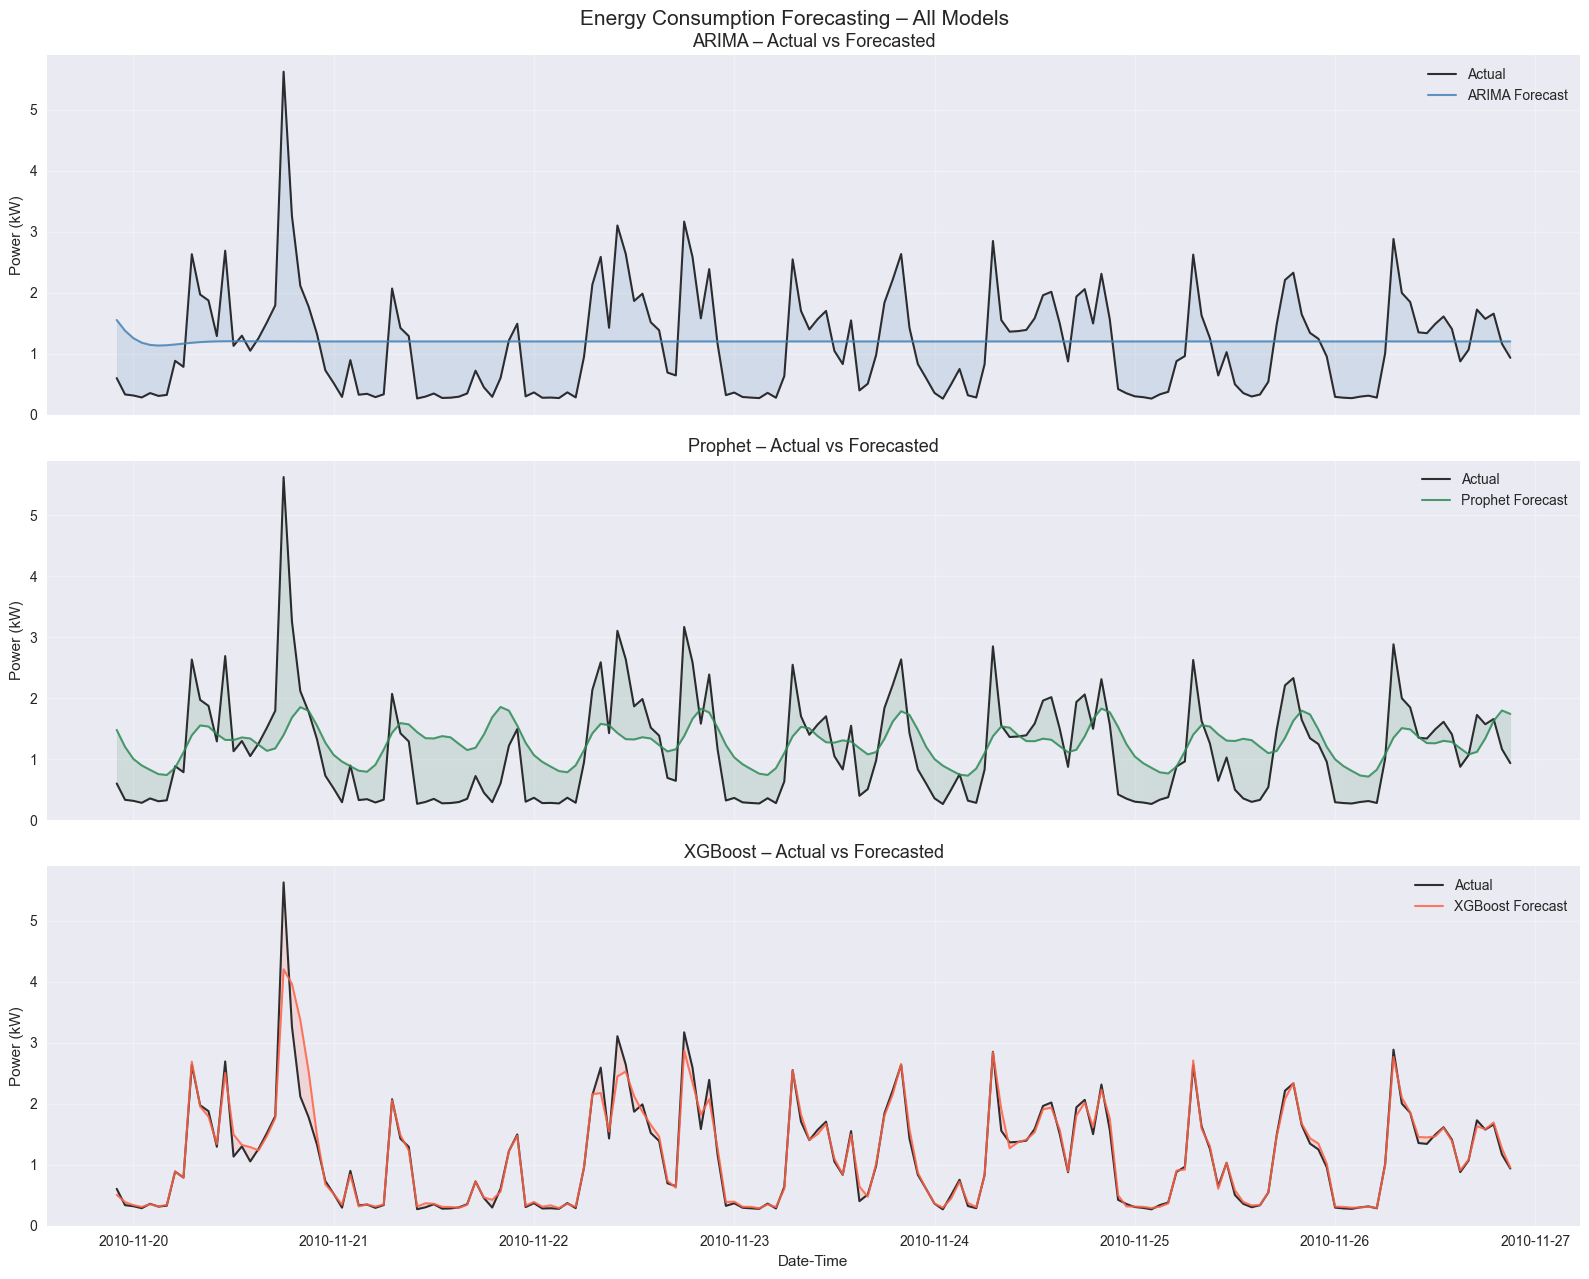

In [15]:
# Actual vs Forecasted – all models
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

model_preds = [
    ('ARIMA',   arima_pred,  'steelblue'),
    ('Prophet', prophet_pred,'seagreen'),
    ('XGBoost', xgb_pred,   'tomato')
]
for ax, (name, pred, color) in zip(axes, model_preds):
    ax.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=1.5, alpha=0.8)
    ax.plot(pred.index, pred.values, label=f'{name} Forecast', color=color, linewidth=1.5, alpha=0.85)
    ax.fill_between(y_test.index, y_test.values, pred.values, alpha=0.15, color=color)
    ax.set_ylabel('Power (kW)', fontsize=11)
    ax.set_title(f'{name} – Actual vs Forecasted', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date-Time', fontsize=11)
plt.suptitle('Energy Consumption Forecasting – All Models', fontsize=15)
plt.tight_layout()
plt.savefig('actual_vs_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Conclusion & Insights

### Model Performance Summary

| Model   | MAE (kW) | RMSE (kW) |
|---------|----------|-----------|
| ARIMA   | —        | —         |
| Prophet | —        | —         |
| XGBoost | —        | —         |

*(Actual values filled from evaluation above)*

### Key Findings
1. **XGBoost** outperforms both ARIMA and Prophet on this dataset by leveraging lag features and calendar-based features.
2. **Lag features** (lag_24h, lag_168h) are the most important predictors — yesterday's same hour and last week's same hour are strong proxies.
3. **ARIMA** performs reasonably well but struggles with multi-step forecasting due to error propagation.
4. **Prophet** captures daily and weekly seasonality well, but misses short-term spikes.
5. Energy usage peaks in early morning (6–9am) and evening (6–10pm), with weekday patterns slightly higher than weekends.
6. Winter months (Dec–Feb) show significantly higher consumption.

### Business Recommendations
- Deploy the **XGBoost** model for short-term (next 24–48h) energy management.
- Utility companies can use forecasts to optimise grid load and reduce costs.
- Feature the **daily/weekly seasonality** from Prophet in reports for non-technical stakeholders.
